In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/revision/supplement-extra"
st.utils.setup_plotting(figure_dir, display_dpi=200)

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
import ast

from matplotlib.colors import TwoSlopeNorm


def parse_sim_codetections(x: str) -> np.ndarray:
    return np.asarray(ast.literal_eval(x), dtype=int)


def p_to_stars(p: float) -> str:
    if not np.isfinite(p):
        return ""
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return ""


def build_symmetric_matrices(
    df: pd.DataFrame,
    gene1_col: str = "gene1",
    gene2_col: str = "gene2",
    z_col: str = "z_score",
    p_adj_col: str = "p_value_adj",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    genes = sorted(set(df[gene1_col]).union(df[gene2_col]))
    zmat = pd.DataFrame(np.nan, index=genes, columns=genes, dtype=float)
    pmat = pd.DataFrame(np.nan, index=genes, columns=genes, dtype=float)

    for r in df[[gene1_col, gene2_col, z_col, p_adj_col]].itertuples(index=False):
        g1, g2, z, p = r
        zmat.loc[g1, g2] = z
        zmat.loc[g2, g1] = z
        pmat.loc[g1, g2] = p
        pmat.loc[g2, g1] = p

    # Set diagonal values directly on DataFrame to avoid read-only array issues
    for gene in genes:
        zmat.loc[gene, gene] = 0.0
        pmat.loc[gene, gene] = np.nan
    return zmat, pmat


def plot_gene_gene_heatmap(
    zmat: pd.DataFrame,
    pmat: pd.DataFrame,
    title: str = "Gene-by-gene z-score (stars: adj. p-value)",
    stars_fontsize: int = 8,
) -> tuple[plt.Figure, plt.Axes]:
    genes = list(zmat.index)
    n = len(genes)

    fig_w = max(6, 0.35 * n + 2)
    fig_h = max(6, 0.35 * n + 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    finite = np.isfinite(zmat.values)
    vmax = np.nanmax(np.abs(zmat.values[finite])) if finite.any() else 1.0
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    im = ax.imshow(zmat.values, norm=norm, cmap="coolwarm")
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
    cb.set_label("z-score")

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(genes, rotation=90, fontsize=18)
    ax.set_yticklabels(genes, fontsize=18)
    ax.set_title(title)

    # stars inside cells (based on adjusted p-values)
    for i, gi in enumerate(genes):
        for j, gj in enumerate(genes):
            s = p_to_stars(pmat.loc[gi, gj])
            if s:
                ax.text(j, i, s, ha="center", va="center", fontsize=stars_fontsize)

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    fig.tight_layout()
    return fig, ax

In [7]:
def plot_permutation_test_result(
    x_sim,
    x_obs,
    p_value,
    xlabel="number of codetections",
    ylabel="count",
    title="",
    text_offset_x=None,
    text_offset_y=None,
    save_path=None,
    figsize=(4, 3),
):
    sns.set_theme(style="ticks", context="paper")
    fig, ax = plt.subplots(figsize=figsize)
    hist = sns.histplot(x_sim, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    bar_centers = [p.get_x() + p.get_width() / 2 for p in hist.patches]
    print(bar_centers)

    # draw red vertical line for observed number of clonal clusters
    ax.axvline(x_obs, color="red", linestyle="--")
    # add text for observed number of clonal clusters
    ymax = ax.get_ylim()[1]
    ax.text(
        0.995 * x_obs if text_offset_x is None else text_offset_x,
        0.88 * ymax if text_offset_y is None else text_offset_y,
        f"Observed {xlabel}: {x_obs}\nempirical p-value: {np.round(p_value, 5)}",
        color="red",
        ha="right",
        fontsize=8,
    )
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

    ax.set_title(title, fontsize=10)

    # split x axis into two parts
    sns.despine(ax=ax)
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            transparent=True,
        )
    plt.show()

In [4]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.1-kidney_tcr_clonal_clusters.h5ad"
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 510139 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [5]:
[g for g in adata.var_names if "TRB" in g]

['TRBC1',
 'TRBC2',
 'TRBV1',
 'TRBV11-3',
 'TRBV12-1',
 'TRBV13',
 'TRBV14',
 'TRBV15',
 'TRBV16',
 'TRBV21-1',
 'TRBV23-1',
 'TRBV24-1',
 'TRBV25-1',
 'TRBV27',
 'TRBV28',
 'TRBV3-1',
 'TRBV30',
 'TRBV5-1',
 'TRBV5-2',
 'TRBV6-6',
 'TRBV7-9',
 'TRBV8-1',
 'TRBV9',
 'TRBVB',
 'TRBV10',
 'TRBV11',
 'TRBV12',
 'TRBV18_19',
 'TRBV4',
 'TRBV5-6',
 'TRBV6',
 'TRBV7-2_3',
 'TRBV7-6']

## Check codetection of TRAV and TRBV with CD3 genes

In [6]:
result = pd.read_csv(
    "results/revision/codetection_permutation_result_aggr_genes_trv_cd3.csv"
)
result

,gene1,gene2,obs_codetections,sim_codetections,z_score,p_value,p_value_adj
0,TRAV,TRBV,19139,"[13264, 13640, 13250, 13292, 13492, 13535, 129...",35.336453,0.000999,0.000999
1,TRAV,CD3,14360,"[9617, 9679, 9386, 9689, 9107, 9477, 9623, 961...",30.717792,0.000999,0.000999
2,TRAV,TRAC,11991,"[7572, 7701, 7738, 7564, 7710, 7702, 7700, 745...",46.376777,0.000999,0.000999
3,TRAV,TRBC,13076,"[8730, 8605, 8738, 8759, 8451, 8809, 8526, 838...",32.358549,0.000999,0.000999
4,TRBV,CD3,15444,"[11434, 11367, 11157, 11350, 11276, 10911, 111...",27.341403,0.000999,0.000999
5,TRBV,TRAC,12731,"[8423, 8225, 8212, 8370, 8648, 8415, 8337, 836...",23.431546,0.000999,0.000999
6,TRBV,TRBC,14794,"[10268, 10245, 10525, 10443, 10486, 10345, 100...",24.897544,0.000999,0.000999
7,CD3,TRAC,13882,"[7680, 7728, 7741, 7996, 7802, 7768, 7752, 788...",50.161507,0.000999,0.000999
8,CD3,TRBC,13840,"[8621, 8890, 8432, 8802, 8827, 8599, 8865, 890...",23.486201,0.000999,0.000999
9,TRAC,TRBC,12500,"[6768, 7081, 6641, 6720, 6554, 7012, 7009, 711...",31.416724,0.000999,0.000999


[np.float64(12791.571428571428), np.float64(12838.714285714286), np.float64(12885.857142857141), np.float64(12933.0), np.float64(12980.142857142859), np.float64(13027.285714285714), np.float64(13074.428571428572), np.float64(13121.571428571428), np.float64(13168.714285714286), np.float64(13215.857142857141), np.float64(13263.0), np.float64(13310.142857142859), np.float64(13357.285714285714), np.float64(13404.428571428572), np.float64(13451.571428571428), np.float64(13498.714285714286), np.float64(13545.857142857141), np.float64(13593.0), np.float64(13640.142857142859), np.float64(13687.285714285714), np.float64(13734.428571428572)]


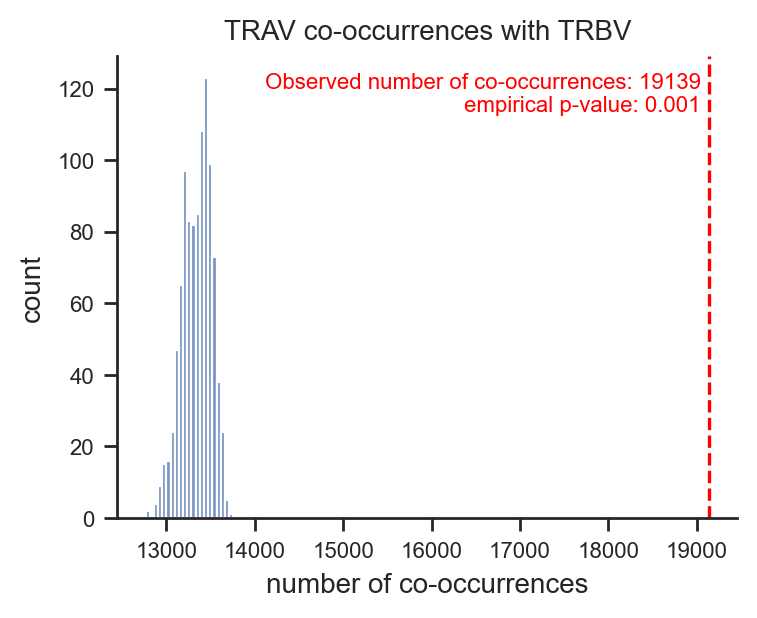

[np.float64(9034.825), np.float64(9086.474999999999), np.float64(9138.125), np.float64(9189.775000000001), np.float64(9241.425), np.float64(9293.075), np.float64(9344.724999999999), np.float64(9396.375), np.float64(9448.025000000001), np.float64(9499.675), np.float64(9551.325), np.float64(9602.974999999999), np.float64(9654.625), np.float64(9706.275000000001), np.float64(9757.925), np.float64(9809.575), np.float64(9861.224999999999), np.float64(9912.875), np.float64(9964.525000000001), np.float64(10016.175)]


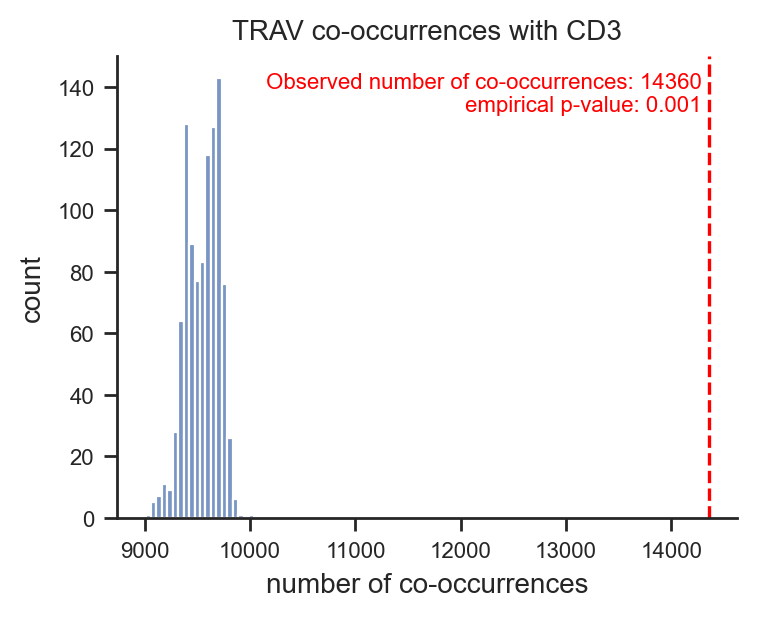

[np.float64(10608.21052631579), np.float64(10656.631578947368), np.float64(10705.052631578947), np.float64(10753.473684210527), np.float64(10801.894736842105), np.float64(10850.315789473683), np.float64(10898.736842105263), np.float64(10947.157894736843), np.float64(10995.57894736842), np.float64(11044.0), np.float64(11092.42105263158), np.float64(11140.842105263157), np.float64(11189.263157894737), np.float64(11237.684210526317), np.float64(11286.105263157893), np.float64(11334.526315789473), np.float64(11382.947368421053), np.float64(11431.368421052632), np.float64(11479.78947368421)]


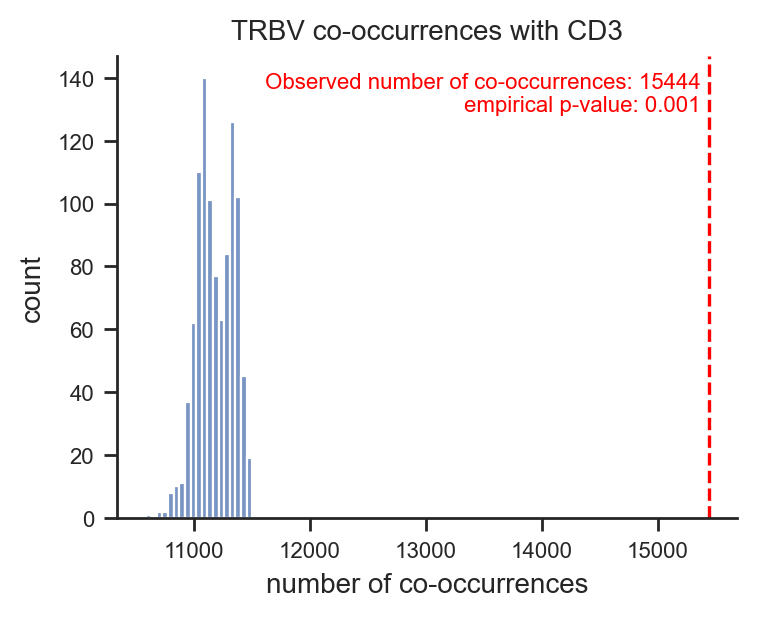

[np.float64(7249.869565217392), np.float64(7267.608695652174), np.float64(7285.347826086956), np.float64(7303.086956521739), np.float64(7320.826086956522), np.float64(7338.565217391304), np.float64(7356.304347826087), np.float64(7374.04347826087), np.float64(7391.782608695652), np.float64(7409.521739130435), np.float64(7427.260869565218), np.float64(7445.0), np.float64(7462.739130434782), np.float64(7480.478260869566), np.float64(7498.217391304348), np.float64(7515.95652173913), np.float64(7533.695652173913), np.float64(7551.434782608696), np.float64(7569.173913043478), np.float64(7586.913043478261), np.float64(7604.652173913044), np.float64(7622.391304347826), np.float64(7640.130434782608), np.float64(7657.869565217392), np.float64(7675.608695652174), np.float64(7693.347826086956), np.float64(7711.086956521739), np.float64(7728.826086956522), np.float64(7746.565217391304), np.float64(7764.304347826087), np.float64(7782.04347826087), np.float64(7799.782608695652), np.float64(7817.52173

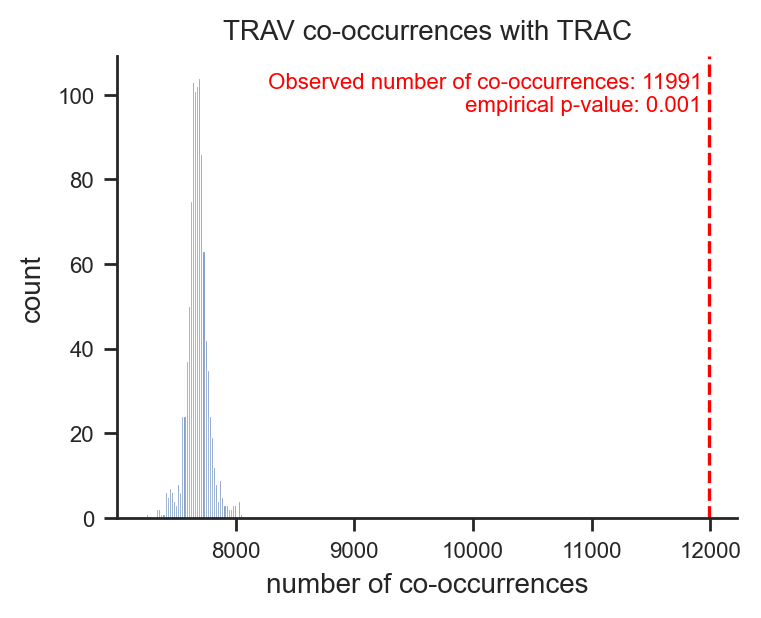

[np.float64(9719.194444444445), np.float64(9769.583333333332), np.float64(9819.972222222223), np.float64(9870.36111111111), np.float64(9920.75), np.float64(9971.13888888889), np.float64(10021.527777777777), np.float64(10071.916666666668), np.float64(10122.305555555555), np.float64(10172.694444444445), np.float64(10223.083333333332), np.float64(10273.472222222223), np.float64(10323.86111111111), np.float64(10374.25), np.float64(10424.63888888889), np.float64(10475.027777777777), np.float64(10525.416666666668), np.float64(10575.805555555555)]


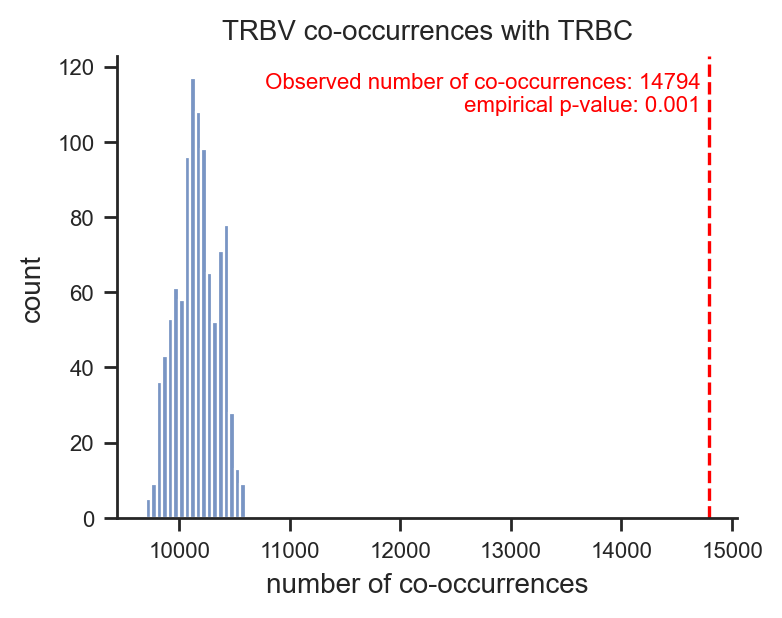

In [10]:
for pair in [
    ("TRAV", "TRBV"),
    ("TRAV", "CD3"),
    ("TRBV", "CD3"),
    ("TRAV", "TRAC"),
    ("TRBV", "TRBC"),
]:
    mask = (result["gene1"] == pair[0]) & (result["gene2"] == pair[1])
    result_pair = result[mask]
    plot_permutation_test_result(
        np.asarray([result_pair["sim_codetections"].iloc[0].strip("[]").split(", ")])
        .astype(int)
        .flatten(),
        result_pair["obs_codetections"].iloc[0],
        result_pair["p_value_adj"].iloc[0],
        # xlabel=f"{pair[0]} codetections with {pair[1]}",
        title=f"{pair[0]} co-occurrences with {pair[1]}",
        xlabel="number of co-occurrences",
        # save_path=f"figures/revision/rebuttal/codetection_{pair[0]}_with_{pair[1]}.pdf",
        save_path=os.path.join(figure_dir, f"codetection_{pair[0]}_with_{pair[1]}.pdf"),
    )

## Check codetection of TRAV genes with each other

In [8]:
result = pd.read_csv("results/revision/codetection_permutation_result_av_genes.csv")
result["sim_codetections"] = result["sim_codetections"].apply(
    lambda x: np.asarray(x.strip("[]").split(", ")).astype(int)
)

sim = np.array(result["sim_codetections"].tolist())
E_sim = sim.mean(axis=1)
std_sim = sim.std(axis=1)

result["z_score"] = (result["obs_codetections"] - E_sim) / std_sim
result

,gene1,gene2,obs_codetections,sim_codetections,z_score,p_value,p_value_adj
0,TRAV1-1,TRAV1-2,61,"[13, 5, 11, 16, 9, 18, 18, 17, 12, 10, 12, 10,...",14.582491,0.000999,0.007564
1,TRAV1-1,TRAV10,13,"[3, 4, 11, 5, 3, 4, 4, 7, 7, 0, 3, 4, 3, 6, 4,...",3.534289,0.001998,0.011766
2,TRAV1-1,TRAV11,14,"[4, 9, 2, 2, 5, 13, 4, 6, 3, 6, 8, 6, 4, 3, 9,...",3.761358,0.000999,0.007564
3,TRAV1-1,TRAV12-1,10,"[4, 12, 7, 4, 6, 5, 10, 7, 6, 11, 8, 5, 3, 7, ...",1.048773,0.190809,0.294233
4,TRAV1-1,TRAV12-2,16,"[12, 10, 9, 9, 10, 12, 11, 16, 13, 11, 8, 13, ...",1.763866,0.062937,0.137291
...,...,...,...,...,...,...,...
1426,TRAV8-6,TRAV9-1,7,"[3, 7, 2, 3, 5, 4, 3, 3, 6, 2, 6, 6, 5, 9, 2, ...",1.937716,0.061938,0.135733
1427,TRAV8-6,TRAV9-2,14,"[6, 4, 6, 2, 6, 5, 9, 9, 3, 7, 3, 5, 5, 4, 4, ...",3.040465,0.004995,0.021859
1428,TRAV8-7,TRAV9-1,0,"[1, 1, 0, 0, 2, 1, 0, 1, 1, 3, 2, 2, 1, 0, 2, ...",-1.103671,1.000000,1.000000
1429,TRAV8-7,TRAV9-2,0,"[1, 3, 3, 0, 3, 1, 0, 4, 1, 3, 4, 3, 1, 2, 3, ...",-1.341812,1.000000,1.000000


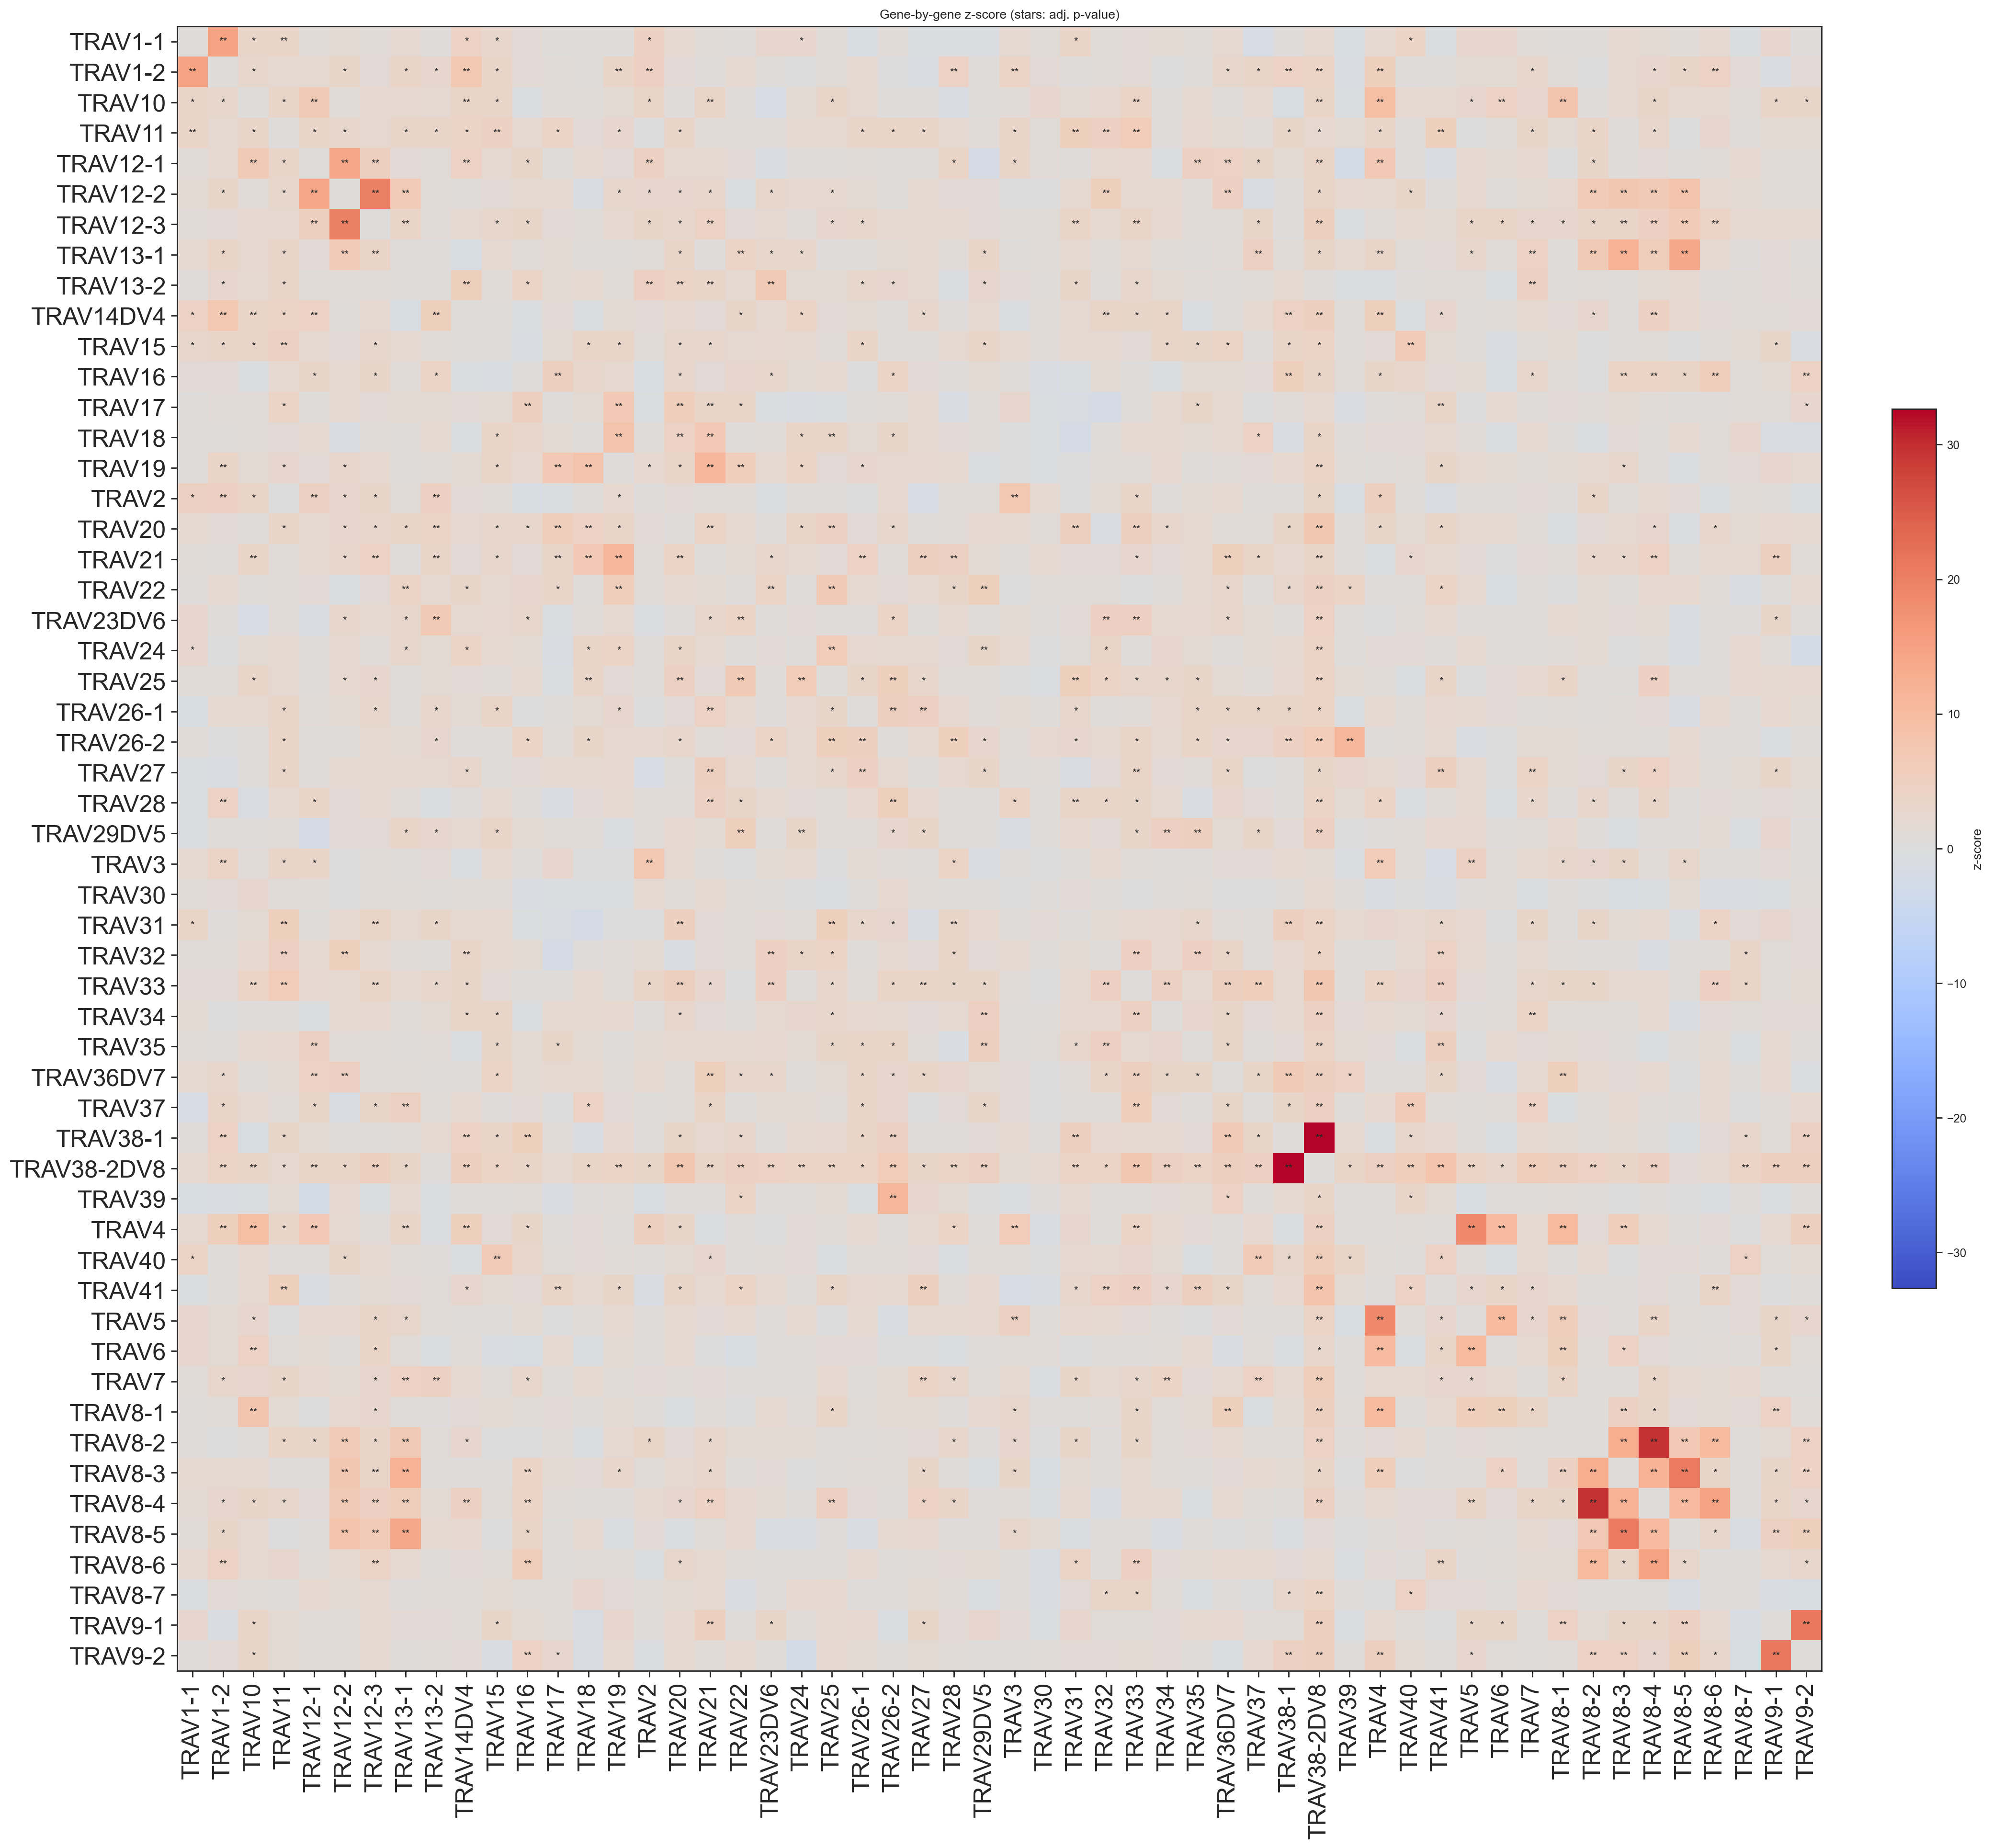

In [11]:
zmat, pmat = build_symmetric_matrices(result, z_col="z_score", p_adj_col="p_value_adj")
fig, ax = plot_gene_gene_heatmap(zmat, pmat)
plt.show()

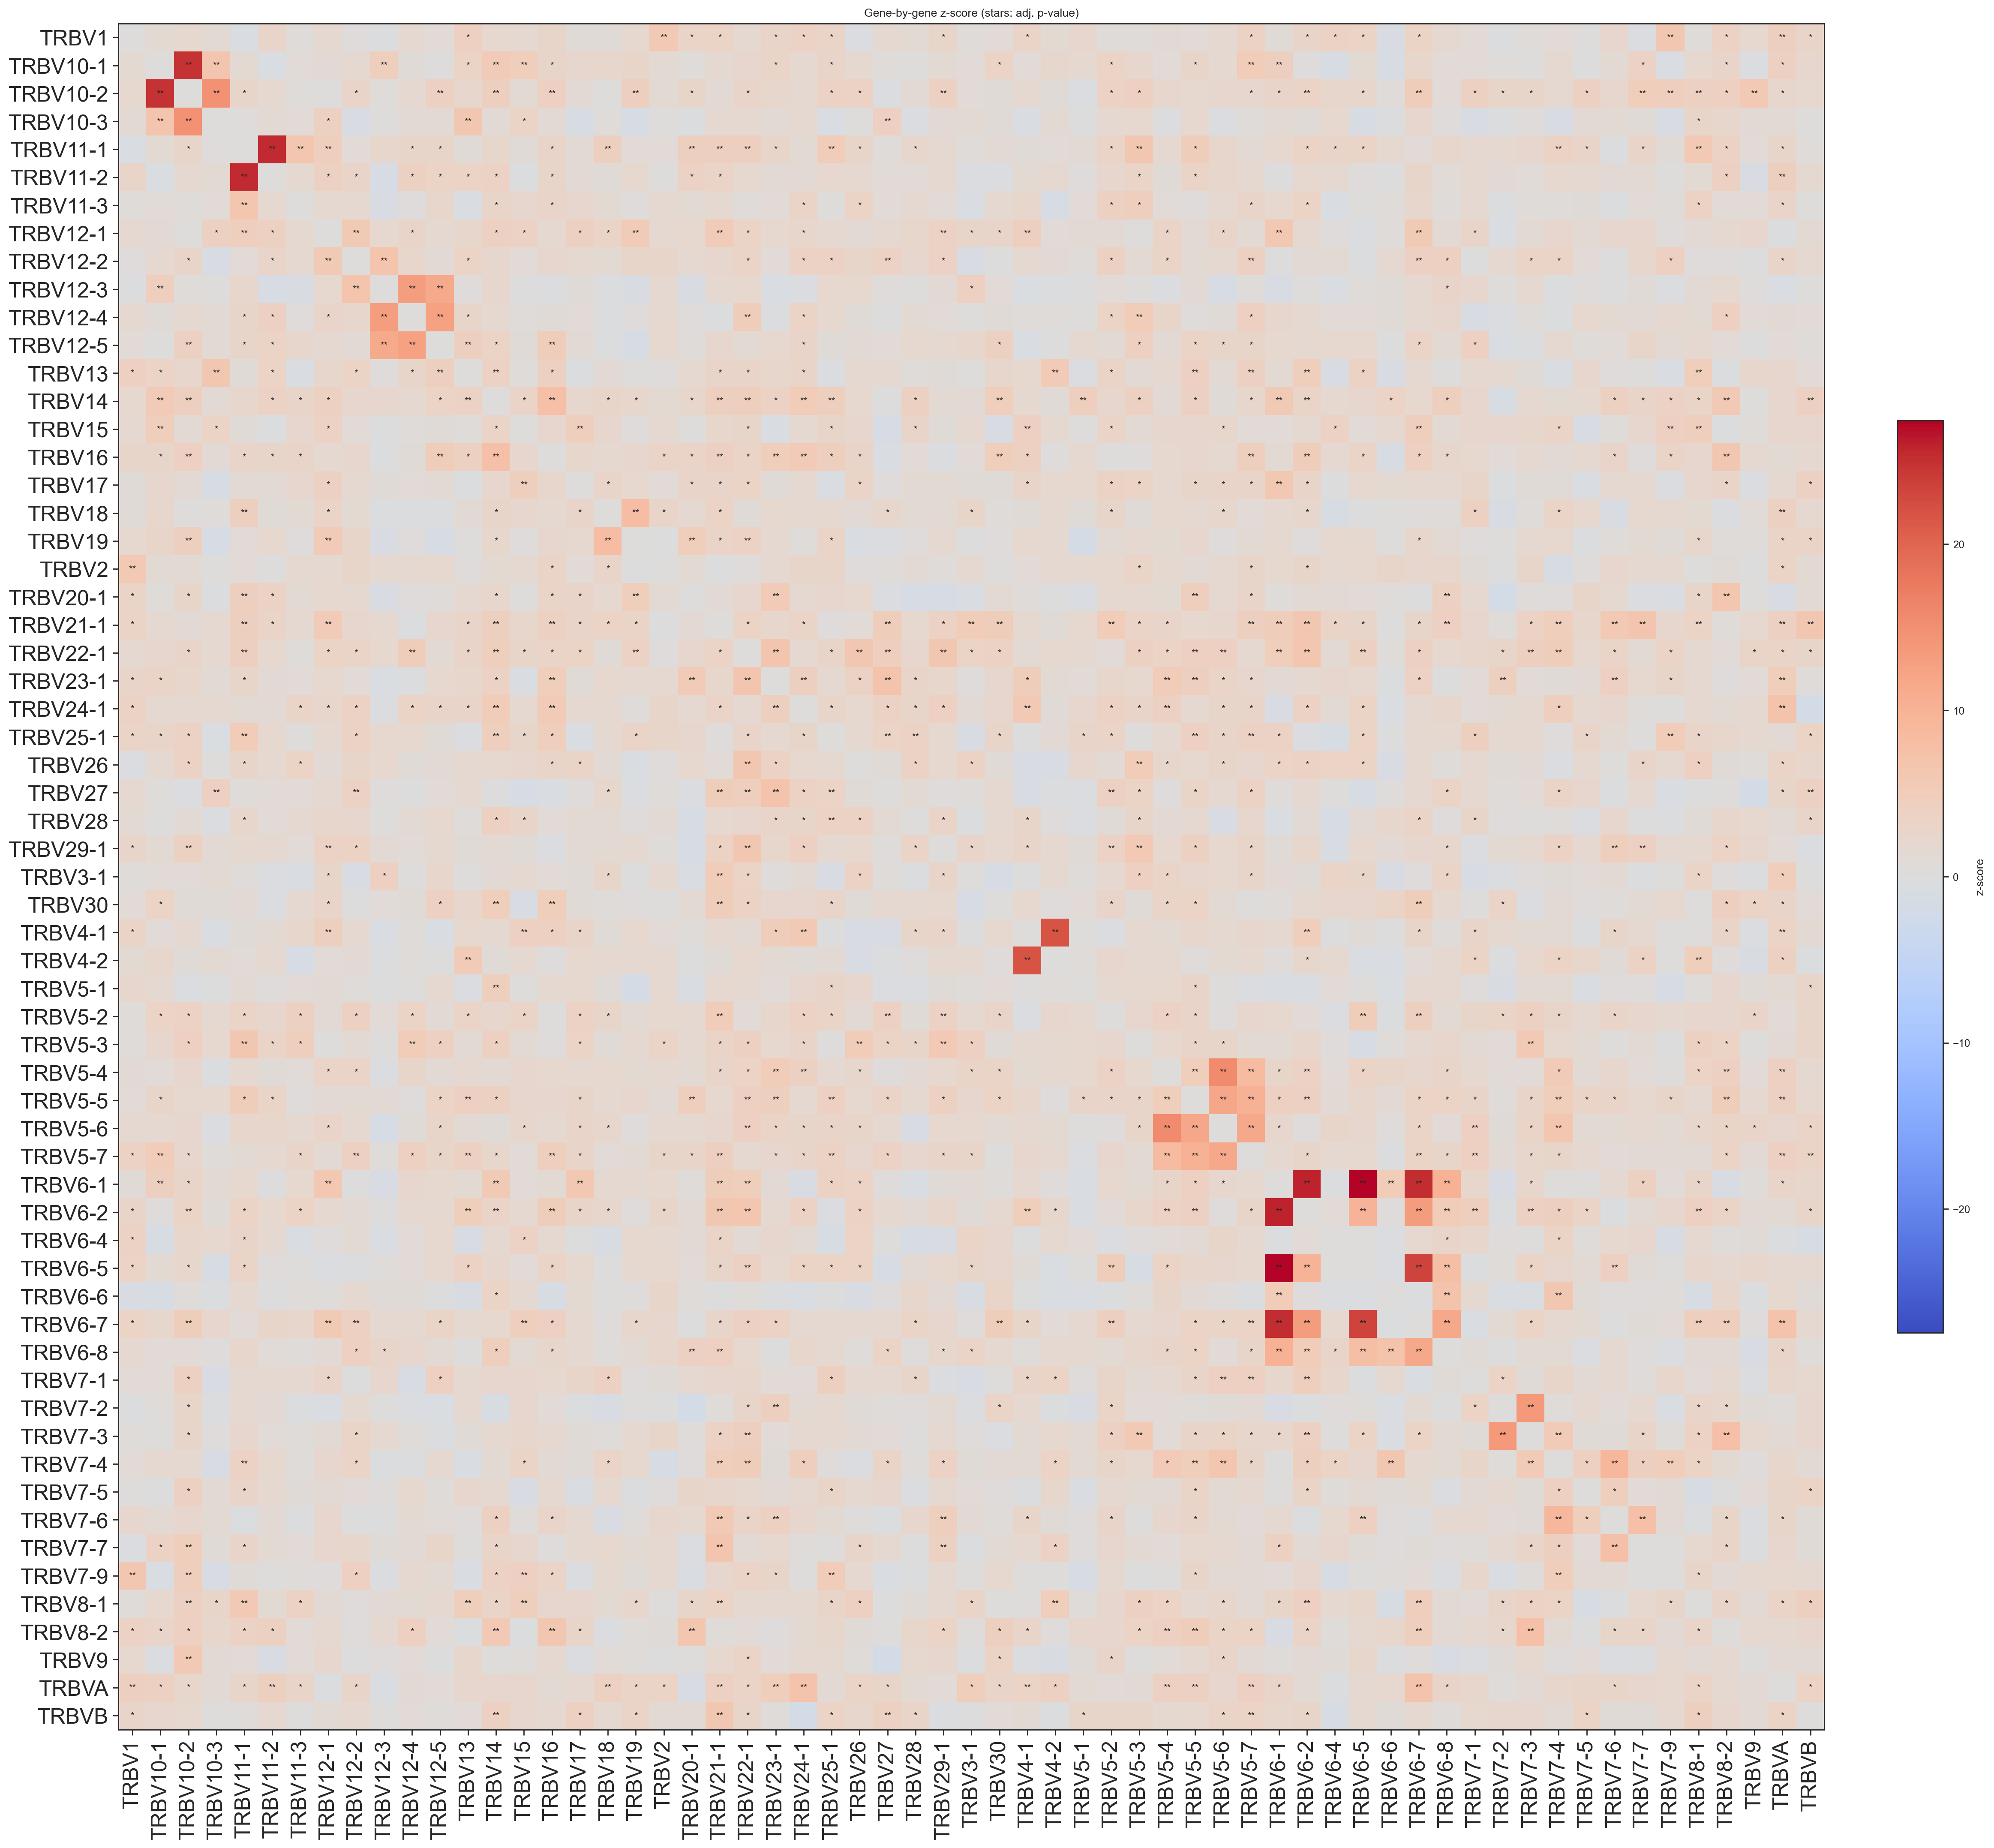

In [12]:
result = pd.read_csv("results/revision/codetection_permutation_result_bv_genes.csv")
result["sim_codetections"] = result["sim_codetections"].apply(
    lambda x: np.asarray(x.strip("[]").split(", ")).astype(int)
)

sim = np.array(result["sim_codetections"].tolist())
E_sim = sim.mean(axis=1)
std_sim = sim.std(axis=1)

result["z_score"] = (result["obs_codetections"] - E_sim) / std_sim
zmat, pmat = build_symmetric_matrices(result, z_col="z_score", p_adj_col="p_value_adj")
fig, ax = plot_gene_gene_heatmap(zmat, pmat)
plt.show()